This collection of examples serves as a valuable reference for utilizing the Jupyter Notebook in the context of mechanical design. It not only demonstrates how to perform calculations, but also delves into the crucial aspect of conducting research in this field. The code closely aligns with the content found in the Roloff & Matek textbook's 6th edition, referencing equation and expression numbers.  
    
You are currently viewing a version of the code that **does not** include comments on how to write the code but instead focuses solely on the technical aspects. The xxx_extended.ipynb files do provide a detailed explanation of how to use the code.   

---

# Assignment

In this assignment, we will design the drive system for a transport belt. The drive will be powered by a geared electromotor and a chain transmission. Here are the initial specifications:

- The output power of the geared motor is given as $P_1 = 3 \: kW$ at an output speed of $n_1 = 125 \:rpm$.
- The desired speed of the shaft driving the transport belt is approximately $n_2 \approx 50 \:rpm$.
- The distance between the output shaft of the geared motor and the shaft driving the transport belt should be approximately $a_0 \approx 1000 \: mm$, with an angle between the shaft-to-shaft line and the horizontal of $\delta \approx 40°$
- For this specific application of the transport belt, we will assume the following use conditions: average starting, full load with moderate jolts, 8 hours of daily use, and a well-lubricated chain.

Your task is to calculate the following:

  a. Determine the number of teeth, $z_1$ and $z_2$, required for the chainwheels.  
  b. Select a suitable roller chain according to DIN 8187.  
  c. Identify the appropriate lubrication to be used.  
  d. Calculate the forces $F_A$ acting on the drive shaft.  

---
 

In [1]:
# import statements
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

import MechDesign.Helpers as HM

from MechDesign.Units.Units import m_, mm_, kg_, s_, N_, rpm_, W_, deg_
import MechDesign.Units.UnitMethods as UM

import MechDesign.RnM as RnM

import matplotlib.pyplot as plt

## a. Gear Ratio
By utilizing the required speeds, we can calculate the gear ratio, denoted as $i$. In a first step we will estimate $i'$.  The final gear ratio will depend on the number of teeth of both chain wheels. 


In [2]:
# creating the chain to be calculated
CH = RnM.Chain()    

In [3]:

CH.i = CH.E17_1B_GearRatioTeeth()
t=HM.EqPrint('i',CH.i)     

Eq(i, _z_2/_z_1)

In [4]:

t=HM.MyHelp(CH.i)
t=0

_z_2/_z_1

    z_1 : [] nr of teeth of the driving chain wheel
    z_2 : [] nr of teeth of the driven chain wheel


we have to determine the values of $z_2$ and $z_1$.  Based on the textbook, we need an intial estimation of the required gear ratio, which we will call $i'$

In [5]:
# setting the value of known parameters
CH.n_1=125 * rpm_    
CH.n_2=50 * rpm_
iprime = CH.n_1/CH.n_2
t=HM.EqPrint('iprime',iprime)

Eq(iprime, 2.5)

For this transmission, the number of teeth mentioned in section 17.2.2 come closest to standard roller chain sizes: $z_1=23$ for the small wheel (selected from the range $z=17...25$, which is favorable for small wheels), and $z_2=57$ for the large wheel (determined by multiplying $z_1=23$ by $i'$ ).  
Therefore, the actual gear ratio becomes $i = z_2/z_1$

In [6]:
CH.z_1 = 23
CH.z_2 = 57

i_result = HM.substitute(CH.i,CH)   
HM.EqPrint('i_result',i_result)

t=HM.EqPrint('i',CH.i)

Eq(i_result, 2.478)

Eq(i, _z_2/_z_1)

In [7]:
CH.i = HM.substitute(CH.i,CH)
t=HM.EqPrint('i',CH.i)

Eq(i, 2.478)

**The solutions to quesion a. is:**
- $z_1 = 23$ with this smaler chain wheel beeing the driving wheel
- $z_2 = 57$ with this bigger geer beeing the driven wheel
  
the gear ratio then becomes $i \approx  2.48$   


---

## b. Chain selection

The selection of the chain size is made using the power diagram (Table 17-3). 
However, since the operating conditions here deviate from the values in the diagram, 
the desired diagram power must be determined according to equation 17.7.

In [8]:
# the main expression to evaluate is the calculation of P_D
CH.P_D = CH.E17_7_DiagramPower()
t=HM.MyHelp(CH.P_D)

_K_A*_P_1*_f_1/(_f_2*_f_3*_f_4*_f_5*_f_6)

    f_4 : [] power factor on number of chain wheels {exp 17.7}
    f_3 : [] power factor on shackle shape {exp 17.7}
    f_1 : [] power factor on number of teeth {table 17-5}
    f_2 : [] power factor on shaft to shaft distance {table 17-6}
    P_1 : [W] input power
    f_6 : [] power factor on working conditions {table 17-7}
    f_5 : [] power factor on lifetime expectancy 
    K_A : [] working condtion factor {table 3-5}


In [9]:
CH.K_A = 1.6     #The operating factor K_A , corresponding to the occurring conditions and according to Table 3-5b
CH.f_1 = 0.8     #Estimating the number of teeth, from Table 17-5, a factor of f_1 = 0.8 is read for z_1=23.
CH.f_2 = 1       #The shaft distance factor f_2 is initially set to 1 because the chain pitch is still unknown.
CH.f_3 = 1       #as we assume an even number of connecting links.
CH.f_4 = 1       #for n = 2
CH.f_5 = 1       #for an, assumed service life of 15000hours
CH.f_6 = 0.9     #according to table 17.7 a dust free environment cannot be guaranteed
#CH.P_1 = 3000*W_ #based on the data in the assignment itself
CH.P_D = HM.substitute(CH.P_D,CH)
t=HM.MyHelp(CH.P_D)

1.422*_P_1

    P_1 : [W] input power


In [10]:
CH.P_1 = 3000*W_ #based on the data in the assignment itself
CH.P_D = HM.substitute(CH.P_D,CH)
t = HM.EqPrint('P_D',CH.P_D)

Eq(P_D, 4267.0*W_)

For this power and for $n_1\approx125$ rpm, we select from Table 17-3:  
DIN 8187 - 16B - 1 : roller chain no. 16B, single strand. The pitch for this chain is $p=25.4$ mm.  
  
For the expected shaft distance $a_0\approx1000$ mm, the number of chain links can be calculated using equation 17.9.

In [11]:
CH.X_0 = CH.E17_9_InitalNrOfShackels()
CH.p = 25.4*mm_       #as foud for the DIN 8187-16B chain
CH.a_0 = 1000*mm_     #as per assignment
CH.X_0 = HM.substitute(CH.X_0,CH)
t=HM.EqPrint('X_0',CH.X_0)

Eq(X_0, 119.5)

Following the recommendations in paragraph 17.2.5, it is preferred to have an even number of links. Therefore, the number of links is set to $X=120$.  
The effective shaft distance, $a$, can be calculated using expression 17.10

In [12]:
CH.X = 120
CH.a = CH.E17_10_ShaftDistance()        
t=HM.EqPrint('a',CH.a.evalf())   

Eq(a, 1007.0*mm_)

**The solution to question b. is:**

- DIN 8187 - 16B - 1x120, chain
- single chain
- 120 links
- shaft distance $a=1007$ mm  


---

## c. lubrication 

The choice of lubrication depends on both the speed $v$ and the chain size (refer to Table 17-8).  
We can determine the speed by considering the diameter $d$ of one of the sprockets, utilizing expression 17.3

In [13]:
# opting to calcuate the speed using the smallest sprocket, opting for expression 17.3B, thus eliminating the need to calculate tau
CH.v = CH.E17_14_h_Speed()  #---Helper expressions within or adjacent to an expression are indicated using '_h_' or '_hA_','_hB_','_hC_,..
HM.EqPrint('v',CH.v)
#since 3B can be used for both d_1 and d_2, z has to be set to z_1 or z_2
CH.d_1 = HM.substitute(CH.E17_3B_PitchDiameter(),CH,z=CH.z_1)       
HM.EqPrint('d_1',CH.d_1)
CH.v = HM.substitute(CH.v,CH)    
t=HM.EqPrint('v',CH.v)

Eq(v, 62.5*_d_1*rpm_)

Eq(d_1, 186.5*mm_)

Eq(v, 11660.0*mm_*rpm_)

In [14]:
CH.v = UM.All_to_SI(CH.v)
t=HM.EqPrint('v',CH.v)

Eq(v, 1.221*m_/s_)

Table 17-8 suggests that at a velocity of $v=1.22 m/s$ and with a size of 16B, drip lubrication (2) could still be used. However, to ensure  reliability, a precautionary measure is taken by opting for an oil bath (3).

**The solution to question c. is:**

- An oil bath is selected as the appropriate lubrication method for the chosen roller chain.

---

## d. Force on the drive shaft

The load on the drive shaft $F_A$ is slightly higher at the upper wheel due to the inclined position of the chain drive, corresponding to the difference between Fsn and Fso2. For the upper wheel, in accordance with equation 17.19, we have $F_A \approx F_t \cdot K_A + 2 \cdot F_{sb}$ , as per expression 17.17.  
The tangential force can be calculated using expression 17.14.


In [15]:
CH.F_sb = CH.E17_17_TopWheelSupportForce()
t=HM.MyHelp(CH.F_sb.evalf())

_g*_l_T*_q*(_Fprime_s + sin(0.005556*_psi*pi/deg_))

    q : [kg/m] chain weight / lenght
    psi : [deg] angle between horizontal and chain contact points line
    Fprime_s : [] relative load factor 
    l_T : [mm] length chain section under tension
    g : [m/s²] gravitationl constant, to be set by user


In [16]:
CH.q = CH.q = 2.7 * kg_/m_          # based on tabel 17-1
CH.Fprime_s = 5                     # based on tabel 17-4
CH.g = 9.81*m_/s_**2                # the chain will be used on Earth
CH.epsilon_0 = CH.E17_17_hB_epsilon_0()
t=HM.MyHelp(CH.epsilon_0.evalf())   

asin(0.07874*(_d_2 - 186.5*mm_)/(mm_*(80.0*(1 - 0.36125/pi**2)**0.5 + 80.0)))

    d_2 : [] pitch diameter of the driven chain wheel


In [17]:
CH.d_2 = HM.substitute(CH.E17_3B_PitchDiameter(),CH,z=CH.z_2)       
HM.EqPrint('d_2',CH.d_2)
CH.epsilon_0 = HM.substitute(CH.epsilon_0,CH)

Eq(d_2, 461.1*mm_)

In [18]:
CH.F_t = CH.E17_14A_TangentialForce()   
CH.F_t = UM.All_to_SI(CH.F_t)
CH.F_t = UM.kgm_s2_to_N(CH.F_t)
t=HM.EqPrint('F_t',CH.F_t)

Eq(F_t, 2457.0*N_)

In [19]:
CH.F_sb = HM.substitute(CH.F_sb,CH)
t=HM.MyHelp(CH.F_sb.evalf())

26.49*_l_T*kg_*(sin(0.005556*_psi*pi/deg_) + 5.0)/s_**2

    psi : [deg] angle between horizontal and chain contact points line
    l_T : [mm] length chain section under tension


Equation 17.17 facilitates the determination of the support force acting on the upper sprocket, but it requires the configuration of several parameters before it can be applied

In [20]:
CH.l_T = CH.a * sp.cos(CH.epsilon_0)
# HM.EqPrint('l_T',CH.l_T.evalf())
CH.delta = 40*deg_       # as given in the assignemt

# CH.psi = CH.E17_17_hA_psi()

CH.F_sb = HM.substitute(CH.F_sb,CH)
CH.F_sb = UM.All_to_SI(CH.F_sb)
CH.F_sb = UM.kgm_s2_to_N(CH.F_sb)
t=HM.EqPrint('F_sb',CH.F_sb)

Eq(F_sb, 26.41*N_*(sin(_psi) + 5.0))

Compared to the circumferential force $F_t$, the support tension $F_{sb}$ is relatively small and can be readily disregarded in this scenario.  
Taking into consideration the operating factor $K_A \approx 1.6$ (refer to part b), the shaft load on the upper sprocket is calculated as:

In [21]:
CH.F_Ab = CH.E17_19B_ShaftSupportForceTopChainWheel()
t=HM.EqPrint('F_Ab',CH.F_Ab)

Eq(F_Ab, 52.83*N_*(sin(_psi) + 5.0) + 3932.0*N_)

**The solution to question d. is:**  
  
- The support force for the upper sprocket will be $F_{Ab} \approx 4225$ N  


---  

*We will now illustrate the process of transitioning from a 'one-point' code to the creation of a graph.*  
We will examine the relationship between $F_{Ab}$ and its dependency on $\psi$.  
*Please examine one of the code blocks above closely, and you will notice that one line of code has been commented out*  
```
# CH.psi = CH.E17_17_hA_psi()
```

*When looking at $F_{Ab}$, you will find it has become a function of $\psi$, which we can evaluate for different values.*  
**When using the eavlate function it is important to assume that all unit symbols in the function to be evaluated will be set to 0**
  

In [22]:
help(HM.evaluate)

Help on function evaluate in module MechDesign.Helpers:

evaluate(MyExpression, inputs)
    evaluate a symbolic expression at set points, using lambda functions
    MyExpression:   symbolic expression
                    can still hold unit symbols, 
                    ALL UNIT SYMBOLS WILL BE SET TO '1'
          inputs:   dictionary with key, value pairs, max 3 pairs
             key:   holds the symbol of to be replaced     
                    alternatively, it can hold the corresponding string to be converted to symbol
          values:   single value, list, or array
                    CANNOT HOLD UNIT SYMBOLS, 
                    double check that units are corresponding to the units of MyExpression



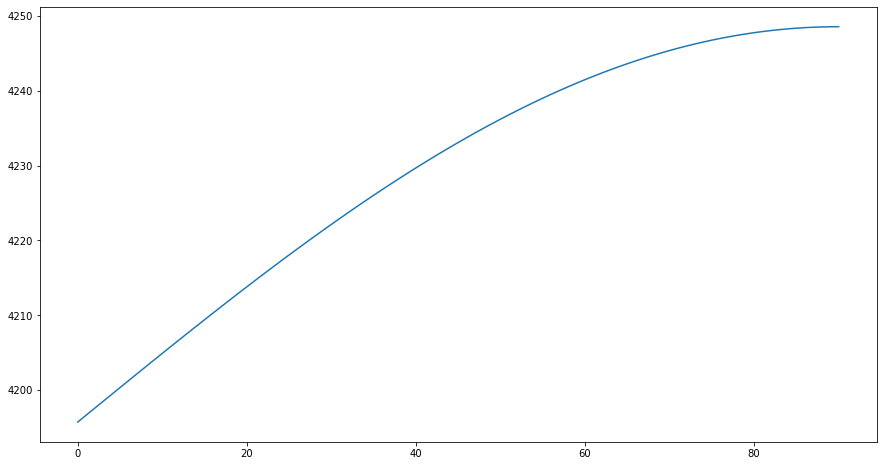

In [23]:
# we want to investigate the change in F_Ab, when psi changes from 0° to 90°
psi_deg = np.arange(0,91,1)                  #---Generating an array, from 0°, to 91°, steps of 1°   ;We did not add a unit ---
psi_rad = [i/180*np.pi for i in psi_deg]     #---since our formula is using 'sin' and all units will be set to 1, we need to convert to rad ---

psi_specific=40                              #---for plotting purposes, we are still interested what happens for psi=40° ---


#--- Calling the evaluate function itself: ---
#--- as will be demonstrated in other examples, you will be able to evaluate for multiple variables at once ---
y = HM.evaluate(CH.F_Ab,{'psi':psi_rad})     

#--- because we want to re-use plotting code, we will copy the values of 'psi_deg' into 'x'
x = psi_deg

# create new figure
fig1,ax1 = plt.subplots(1,1,figsize=(15, 8))  #---A figure can have multiple subplots, and in this example we set the size to 15x8 
t=ax1.plot( x, y, label = f'$F_{{Ab}}$', linestyle = '-', linewidth = 1.5)      #---This will generate a first graph, which will further detail. 

*We will gradualy extend the code for creating this figure, adding more information*

Eq(F_Ab, 52.83*N_*(sin(_psi) + 5.0) + 3932.0*N_)

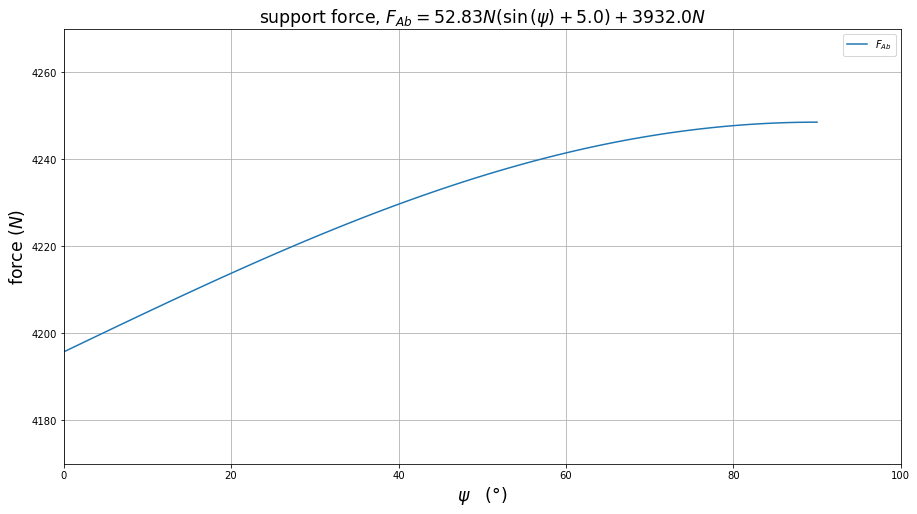

In [24]:
# create new figure
fig2,ax2 = plt.subplots(1,1,figsize=(15, 8))  #---A figure can have multiple subplots, and in this example we set the size to 15x8 ---
ax2.plot( x, y, label = f'$F_{{Ab}}$', linestyle = '-', linewidth = 1.5)      #--- the 'f-string' is formated such that it takes a LateX expression ---
ax2.legend()            #---generates a legend 
# setting a textsize parameter we can re-use in different sections of the code
textsize='xx-large'
# cleaning up the figure
ax2.set_xlabel(f'$\psi$   $(°)$',fontsize=textsize)
ax2.set_ylabel(f'force $(N)$',fontsize=textsize)
Equation = HM.EqPrint('F_Ab',CH.F_Ab) #--using the MD.EqPrint method to generate an equation to be used in the title ---
ax2.set_title((f'support force, $' + sp.latex(Equation) +'$'),fontsize=textsize)
ax2.grid()
plt.xlim([0,100])
t=plt.ylim([4170,4270])

Eq(F_Ab, 52.83*N_*(sin(_psi) + 5.0) + 3932.0*N_)

'the effect of the angle is mimited to 52.826 N, equivalent to 1.25 %'

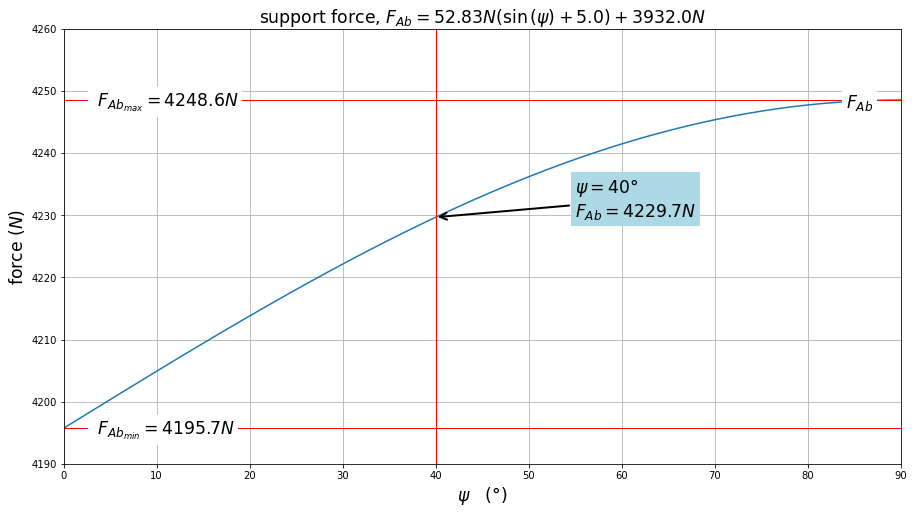

In [26]:
# create new figure
fig3,ax3 = plt.subplots(1,1,figsize=(15, 8))  #---A figure can have multiple subplots, and in this example we set the size to 15x8 ---
ax3.plot( x, y, label = f'$F_{{Ab}}$', linestyle = '-', linewidth = 1.5)      #--- the 'f-string' is formated such that it takes a LateX expression ---
# setting a textsize parameter we can re-use in different sections of the code
textsize='xx-large'
# cleaning up the figure
ax3.set_xlabel(f'$\psi$   $(°)$',fontsize=textsize)
ax3.set_ylabel(f'force $(N)$',fontsize=textsize)
Equation = HM.EqPrint('F_Ab',CH.F_Ab) #--using the MD.EqPrint method to generate an equation to be used in the title ---
ax3.set_title((f'support force, $' + sp.latex(Equation) +'$'),fontsize=textsize)
ax3.grid()
plt.xlim([0,90])
plt.ylim([4190,4260])

#--- adding some more info on the graph ---
# retreiving the maximum value for y
y_max = np.max(y)
y_min = np.min(y)
y_range = y_max-y_min
# finding the y values that corresonds to a specific x value
x_index = (np.abs(psi_deg - psi_specific)).argmin()
y_intersect=y[x_index]
display(f'the effect of the angle is mimited to {y_range:.3f} N, equivalent to {100*y_range/y_intersect:.2f} %')

ax3.annotate(f'$F_{{Ab}}$',xy=(psi_deg[-8],y[-8]),xytext=(10,0-5)     #---in stead of using a legend, we can name the plot 'on the line'
             ,textcoords="offset points",size=textsize
             ,bbox=dict(facecolor='white',edgecolor='none'))
#---indicating the intersection point for psi-specific ---
ax3.axvline(x=psi_specific,linewidth=1, color='r')
ax3.annotate(f'$\psi = {psi_specific} °$\n$F_{{Ab}}= {y_intersect:.1f} N$'
             ,xy=(psi_specific,y_intersect),xytext=(55,y_intersect),size=textsize
             ,arrowprops=dict(arrowstyle='->', color='black', linewidth=2)
             ,bbox=dict(facecolor='lightblue',edgecolor='none'))
#---creating a visual representation of the maximum F_Ab found
ax3.axhline(y=y_max,linewidth=1, color='r')
t=ax3.text(3,y_max-1,f' $F_{{Ab_{{max}}}}= {y_max:.1f} N$',size=textsize, bbox=dict(facecolor='white',edgecolor='none'))
ax3.axhline(y=y_min,linewidth=1, color='r')
t=ax3.text(3,y_min-1,f' $F_{{Ab_{{min}}}}= {y_min:.1f} N$',size=textsize, bbox=dict(facecolor='white',edgecolor='none'))

When a DIN 8187 - 16B - 1x120 chain is employed to convey $P_1=3kW$ of power, with the shaft-to-shaft alignment $\psi=40°$ from the horizontal, this results in a support force of $F_{Ab}\approx4230N$ on the upper sprocket shaft.  

Upon investigating the influence of $\psi$, the angle between the horizontal and the shaft-to-shaft line, it was determined that $\psi$ only contributes a marginal effect of $53N$ ($1.25\%$ of the total shaft load). This outcome aligns with expectations since the predominant forces at play originate from power transmission and the consequent tension in the chain.  

In contrast, if an equivalent belt were to be used, the shaft forces would be significantly higher. Belts utilize friction to transfer power from the belt to the pulley ($Roloff\&Matek^1$). To maintain sufficient frictional force, both sides of the belt must remain under tension, resulting in an increased shaft load.  An analysis of the values of this force is outside the scope of this document.  
  
$ .^1$ : Herbert Wittel, Dieter Jannasch, Joachim Voßiek, Christian Spura, *Chapter 16: riemen* in *Roloff/Matek: Machineonderdelen theorieboek (6e druk)* Amsterdam, Boom uitgeverij, 2021,  ISBN: 9789024428670